<a href="https://colab.research.google.com/github/litlig/notebooks/blob/main/normalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Normalization and training performance

Every ML training is minimizing a loss function with respect to the model weights, and stochastic gradient descent is the basis of approach to move the weights towards the optimal solution. It's like you are walking in a foggy forest and you need to find the lowest valley. Each time you check you footing you only get a noisy local reading based on the few landmarks you happen to grap. The quality of the landmarks decides how far you can reach toward your goal.

Normalization is one of most commonly used approach to improve training performance and achieve a higher stable training rate. The key idea is to shift and scale the input distribution before passing through the non-linear activation function. Commonly used normalizations are batch norm, layer norm and group norm. This notebook will use a simple MLP neural net on the MNIST dataset to illustrate.


### Set up

Below implements a basic fully-connected neural network to classify digits from the MNIST dataset:
- Input: 28x28 binary image (flattened to 784 features)
- Hidden Layers: 3 fully-connected layers, each with 100 activations and sigmoid non-linearity.
- Output Layer: Fully-connected layer with 10 activations (one per class) and softmax for classification.
- Loss Function: Categorical Cross-entropy.

100%|██████████| 9.91M/9.91M [00:00<00:00, 35.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 965kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.60MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.53MB/s]


Number of training samples: 60000
Number of test samples: 10000


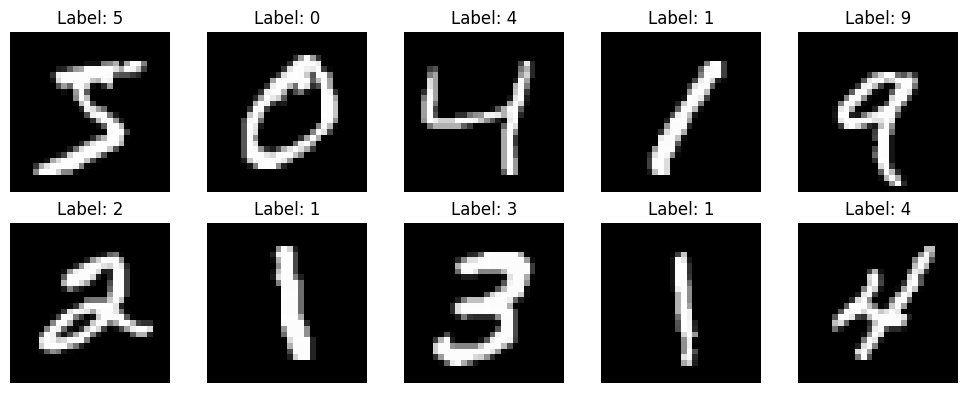

In [1]:
#@title Load dataset
import matplotlib.pyplot as plt
from torchvision import datasets
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Download MNIST
train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())
print(f"Number of training samples: {len(train_data)}")
print(f"Number of test samples: {len(test_data)}")

# Show first 10 samples
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    image, label = train_data[i]

    # Fix: Squeeze the channel dimension and convert to numpy for imshow
    ax.imshow(image.squeeze(0).numpy(), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

to_tensor = transforms.ToTensor()
# Define data loaders for mini-batch training
batch_size = 64
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

In [2]:
#@title Simple MLP network
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = 28*28
dim_hidden = 128
lr = 0.01
n_epoch = 2 # how many epoch we train for

class MLPLayer(nn.Module):
  def __init__(self, input_dim, hidden_dim, activation):
    super(MLPLayer, self).__init__()
    self.linear = nn.Linear(input_dim, hidden_dim)
    self.activation = activation()

  def forward(self, x):
    return self.activation(self.linear(x))


class SimpleNN(nn.Module):
    def __init__(self, n_layer, layerNN, activationNN=nn.ReLU):
        super(SimpleNN, self).__init__()
        self.flatten = nn.Flatten()
        self.mlp = nn.Sequential()
        self.mlp.append(layerNN(input_dim, dim_hidden, activationNN))
        for _ in range(n_layer - 1):
            self.mlp.append(layerNN(dim_hidden, dim_hidden, activationNN))
        self.mlp.append(nn.Linear(dim_hidden, 10))

    def forward(self, x):
        x = self.flatten(x)
        x = self.mlp(x)
        return x

mlp_model = SimpleNN(n_layer=3, layerNN=MLPLayer).to(device)
print(mlp_model)

def train(model):
    model.train()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    step_count = 0
    epoch = 0
    losses = []
    for epoch in range(n_epoch):
        epoch += 1
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = nn.CrossEntropyLoss()(output, target)
            losses.append(loss.item())
            loss.backward()
            optimizer.step()

            step_count += 1

    print(f"Training finished after {step_count} steps.")
    return losses

mlp_losses = train(mlp_model)

SimpleNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (mlp): Sequential(
    (0): MLPLayer(
      (linear): Linear(in_features=784, out_features=128, bias=True)
      (activation): ReLU()
    )
    (1): MLPLayer(
      (linear): Linear(in_features=128, out_features=128, bias=True)
      (activation): ReLU()
    )
    (2): MLPLayer(
      (linear): Linear(in_features=128, out_features=128, bias=True)
      (activation): ReLU()
    )
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)
Training finished after 1876 steps.


### Batch normalization
[Reference paper](https://arxiv.org/pdf/1502.03167)

Deep nn training often run into the problem called covariates shift and non-linearity saturation. That's during the training, the covariates passed to the non-linear activations function can shift to saturation domain, leading to vanishing gradient and slow down the training.

Batch normalization brings the covariates back to a favorable domain by shifting and scaling:
$$ \widehat{x} =  \frac{x - μ}{σ}$$
where μ is the mean value and $σ$ is the std over the mini batch.

In neural nets, there are always linear layers to aggregate information across hidden dim before we feed it to non-linear activation function, $z = Wx+b$. Scaling and shifting x does not lose information because these can be absorbed by W and b. However, neural nets adjusts W and b based on gradient descent in training, stablizing covariates distribution is not in its consideration and this can often lead to poor training perf. Batch norm designed a way to keep the covariates statistics stable. To account for the scale and shift that's really needed by the net, it introduced addtional trainable paramaters, so the input to activation becomes: $γ\widehat{x} + β$.


Note batch norm is based on the assumption that the stats for the mini batch represents the overall population fairly well, it often performs poorly when batch size is too small.







In [3]:
#@title Adding batchnorm before activation
class BatchNormMLP(nn.Module):
  def __init__(self, input_dim, hidden_dim, activation):
    super(BatchNormMLP, self).__init__()
    self.linear = nn.Linear(input_dim, hidden_dim, bias=False)
    self.gamma = nn.Parameter(torch.ones(hidden_dim))
    self.beta = nn.Parameter(torch.zeros(hidden_dim))
    self.activation = activation()
    self.running_mean = torch.zeros(hidden_dim, device=device)
    self.running_var = torch.ones(hidden_dim, device=device)


  def forward(self, x):
    epsion = 1e-4
    momentum = 0.1
    x = self.linear(x) # B:hidden_dim
    if self.training:
        mean = x.mean(dim=0) # hidden_dim
        var = x.var(dim=0, unbiased=False)
        with torch.no_grad():
            self.running_mean = self.running_mean * (1 - momentum) + mean * momentum
            self.running_var = self.running_var * (1 - momentum) + x.var(dim=0, unbiased=True) * momentum
        x = (x - mean) / torch.sqrt(var + epsion)
    else:
        x = (x - self.running_mean) / torch.sqrt(self.running_var + epsion)
    x = x * self.gamma + self.beta
    return self.activation(x)

bn_model = SimpleNN(n_layer=3, layerNN=BatchNormMLP).to(device)
print(bn_model)
bn_losses = train(bn_model)

SimpleNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (mlp): Sequential(
    (0): BatchNormMLP(
      (linear): Linear(in_features=784, out_features=128, bias=False)
      (activation): ReLU()
    )
    (1): BatchNormMLP(
      (linear): Linear(in_features=128, out_features=128, bias=False)
      (activation): ReLU()
    )
    (2): BatchNormMLP(
      (linear): Linear(in_features=128, out_features=128, bias=False)
      (activation): ReLU()
    )
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)
Training finished after 1876 steps.


### Layer normalization
Batch norm does normalization across batch samples for each neuron on a hidden layer, while layer norm treats each sample individually and does normalization across all neurons for each sample:
$$ \widehat{x_i} = \frac{x_i - \mu_i}{\sigma_i}$$
$x_i$ is a sample vector that has d dimensions. For each sample, it:
1. projects x onto the (d-1) dimensional subspace where $Σ_j x_{ij} = 0$.
2. Dividing by $σ$ to fixe the norm to 1.

Unlike batch norm, layer norm transformation is not fully recoverable by linear transformation nor the affine step. It reduces the feature dimension by 2, as shown by the following example, the 3-d x is now confined to a circle.

Layer norm assumes that the direction (centered) of a sample carries the information, and the mean and scale are redudant. Even though it is a genuine inductive bias, it's often a good bet in practice.

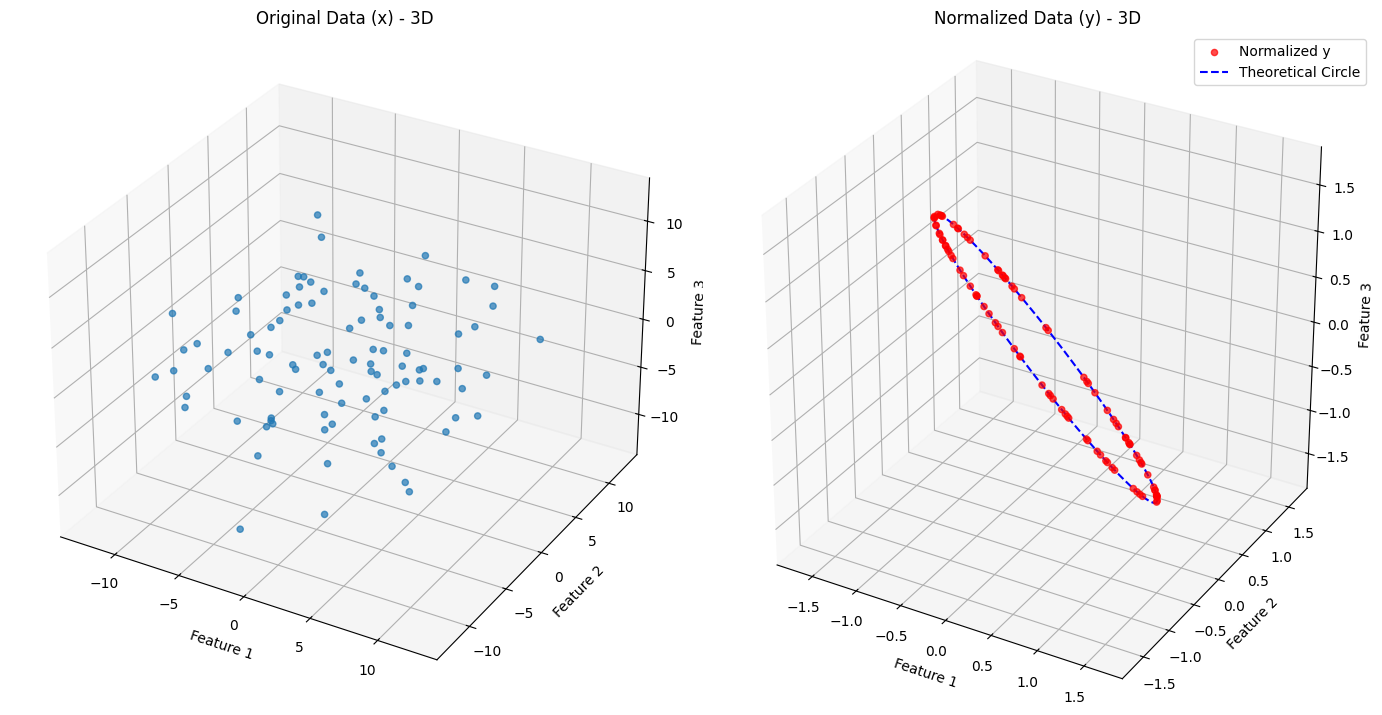

In [4]:
#@title layer norm viz
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Import Axes3D for 3D projection

# Original data generation
x = torch.randn(100,3)*5
mean = x.mean(dim=1, keepdim=True)
var = x.var(dim=1, unbiased=False, keepdim=True)
y = (x - mean) / torch.sqrt(var + 1e-5)

# Create a figure with two 3D subplots
fig = plt.figure(figsize=(14, 7))

# Plot for original x
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(x[:, 0].numpy(), x[:, 1].numpy(), x[:, 2].numpy(), label='Original x', alpha=0.7)
ax1.set_title('Original Data (x) - 3D')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_zlabel('Feature 3')
# Setting a consistent range for x for better comparison, though x is broad
x_max_abs = x.abs().max().item()
ax1.set_xlim([-x_max_abs, x_max_abs])
ax1.set_ylim([-x_max_abs, x_max_abs])
ax1.set_zlim([-x_max_abs, x_max_abs])

# Plot for normalized y
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(y[:, 0].numpy(), y[:, 1].numpy(), y[:, 2].numpy(), label='Normalized y', color='red', alpha=0.7)
ax2.set_title('Normalized Data (y) - 3D')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.set_zlabel('Feature 3')

# Add the theoretical circle for y
R = torch.sqrt(torch.tensor(3.0)) # Radius of the sphere on which y points lie (since variance=1 and dim=3)
# Two orthogonal unit vectors spanning the plane x1 + x2 + x3 = 0
# For a 3D vector [a, b, c], if mean is 0, then a+b+c=0. If variance is 1, then a^2+b^2+c^2 = 3.
# The intersection of the plane x+y+z=0 and sphere x^2+y^2+z^2=3 is a circle.
# We can parameterize this circle using two orthonormal basis vectors for the plane.
u1 = torch.tensor([1/torch.sqrt(torch.tensor(2.0)), -1/torch.sqrt(torch.tensor(2.0)), 0.0])
u2 = torch.tensor([1/torch.sqrt(torch.tensor(6.0)), 1/torch.sqrt(torch.tensor(6.0)), -2/torch.sqrt(torch.tensor(6.0))])

t = torch.linspace(0, 2 * torch.pi, 100) # Angles for the circle
circle_x = R * torch.cos(t) * u1[0] + R * torch.sin(t) * u2[0]
circle_y = R * torch.cos(t) * u1[1] + R * torch.sin(t) * u2[1]
circle_z = R * torch.cos(t) * u1[2] + R * torch.sin(t) * u2[2]

ax2.plot(circle_x.numpy(), circle_y.numpy(), circle_z.numpy(), color='blue', linestyle='--', label='Theoretical Circle')
ax2.legend()
# Adjust limits for ax2 to be cubic to emphasize spherical/circular nature
max_val_y = y.abs().max().item() * 1.1 # add some padding
# Ensure the limits are symmetric around zero and encompass the theoretical circle
lim = max(max_val_y, R.item() * 1.1)
ax2.set_xlim([-lim, lim])
ax2.set_ylim([-lim, lim])
ax2.set_zlim([-lim, lim])
ax2.set_box_aspect([1,1,1]) # This is crucial for the circle to appear circular

plt.tight_layout()
plt.show()

In [5]:
#@title Adding layernorm before activation
class LayerNormMLP(nn.Module):
  def __init__(self, input_dim, hidden_dim, activation):
    super(LayerNormMLP, self).__init__()
    self.linear = nn.Linear(input_dim, hidden_dim, bias=False)
    self.gamma = nn.Parameter(torch.ones(hidden_dim))
    self.beta = nn.Parameter(torch.zeros(hidden_dim))
    self.activation = activation()

  def forward(self, x):
    epsion = 1e-4
    x = self.linear(x) # B:hidden_dim
    mean = x.mean(dim=1, keepdim=True) # B:1
    var = x.var(dim=1, unbiased=False, keepdim=True) # B:1
    x = (x - mean) / torch.sqrt(var + epsion)
    x = x * self.gamma + self.beta
    return self.activation(x)

ln_model = SimpleNN(n_layer=3, layerNN=LayerNormMLP).to(device)
print(ln_model)
ln_losses = train(ln_model)

SimpleNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (mlp): Sequential(
    (0): LayerNormMLP(
      (linear): Linear(in_features=784, out_features=128, bias=False)
      (activation): ReLU()
    )
    (1): LayerNormMLP(
      (linear): Linear(in_features=128, out_features=128, bias=False)
      (activation): ReLU()
    )
    (2): LayerNormMLP(
      (linear): Linear(in_features=128, out_features=128, bias=False)
      (activation): ReLU()
    )
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)
Training finished after 1876 steps.


### Group normalization

Group norm takes a step further on layer norm, instead of normalization across all features in one layer, it breaks features into groups, and each group normalize based on the group mean and std. The theory behind it is: each group can have very different statistics in nature and they should not be pool together to calculate the mean and variance.

Group norm further reduces the degree of freedom to $d-2g$, where d is the total feature dim and g is the number of groups, in exchange for not letting heterogeneous groups pollute each other's statistics. It was introduced for vision models with small batch sizes: channel groups (e.g., from grouped convolutions, or filters tuned to different frequencies/orientations) can have genuinely different natural scales, and pooling all of them into one LayerNorm-style mean/variance would wash out that structure.


In [6]:
#@title Adding group norm before activation
class GroupNormMLP(nn.Module):
  def __init__(self, input_dim, hidden_dim, activation, n_group = 4):
    super(GroupNormMLP, self).__init__()
    assert hidden_dim % n_group == 0, "hidden_dim must be divisible by n_group"
    self.hidden_dim = hidden_dim
    self.linear = nn.Linear(input_dim, hidden_dim, bias=False)
    self.gamma = nn.Parameter(torch.ones(hidden_dim))
    self.beta = nn.Parameter(torch.zeros(hidden_dim))
    self.activation = activation()
    self.n_group = n_group

  def forward(self, x):
    epsion = 1e-4
    B = x.shape[0]
    x = self.linear(x).view(B, self.n_group, self.hidden_dim//self.n_group) # B:group:dim/group
    mean = x.mean(dim=2, keepdim=True) # B:group:dim/group
    var = x.var(dim=2, unbiased=False, keepdim=True) # B:group:dim/group
    x = (x - mean) / torch.sqrt(var + epsion)
    x = x.view(B, self.hidden_dim)
    x = x * self.gamma + self.beta
    return self.activation(x)

gn_model = SimpleNN(n_layer=3, layerNN=GroupNormMLP).to(device)
print(gn_model)
gn_losses = train(gn_model)

SimpleNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (mlp): Sequential(
    (0): GroupNormMLP(
      (linear): Linear(in_features=784, out_features=128, bias=False)
      (activation): ReLU()
    )
    (1): GroupNormMLP(
      (linear): Linear(in_features=128, out_features=128, bias=False)
      (activation): ReLU()
    )
    (2): GroupNormMLP(
      (linear): Linear(in_features=128, out_features=128, bias=False)
      (activation): ReLU()
    )
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)
Training finished after 1876 steps.


### Results across all models
We compare the 4 models (1 vanilla MLp and 3 MLP with different normalizations) in terms of:
- training speed
- evaluation results on test data set
- neuron activation



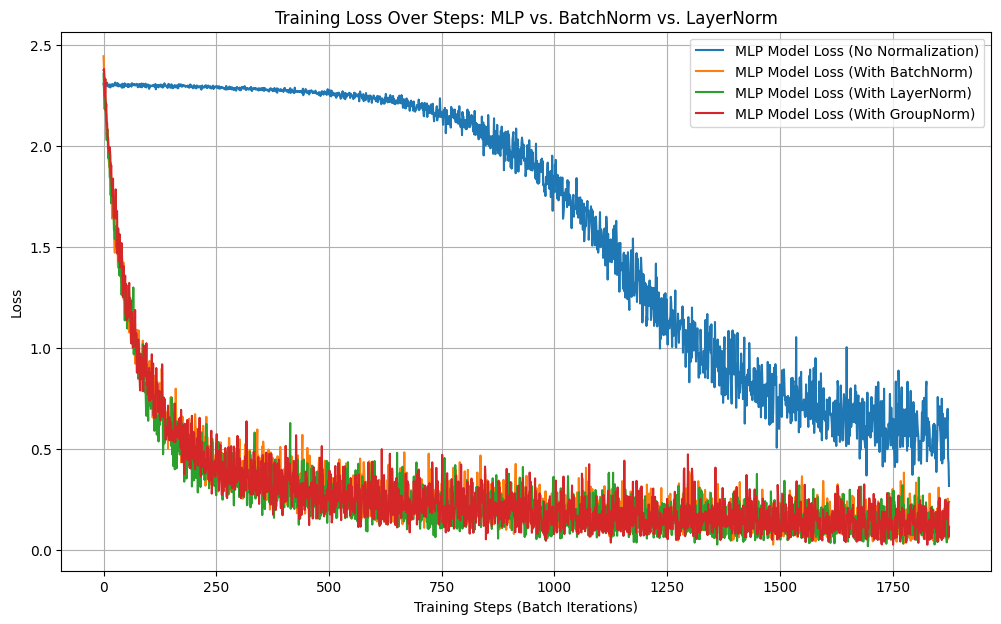

In [7]:
#@title Training losses
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
plt.plot(mlp_losses, label='MLP Model Loss (No Normalization)')
plt.plot(bn_losses, label='MLP Model Loss (With BatchNorm)')
plt.plot(ln_losses, label='MLP Model Loss (With LayerNorm)')
plt.plot(gn_losses, label='MLP Model Loss (With GroupNorm)')
plt.title('Training Loss Over Steps: MLP vs. BatchNorm vs. LayerNorm')
plt.xlabel('Training Steps (Batch Iterations)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
#@title Evaluation on test data
model_names = ['MLP', 'BatchNorm MLP', 'LayerNorm MLP', 'GroupNorm MLP']
models = [mlp_model, bn_model, ln_model, gn_model]
accuracies = []

print('Evaluating models on test data:')
for name, model in zip(model_names, models):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    accuracy = 100 * correct / total
    accuracies.append(accuracy)

import pandas as pd

# Create a DataFrame from the model names and accuracies
results_df = pd.DataFrame({
    'Model Type': model_names,
    'Accuracy (%)': accuracies
})

# Display the DataFrame
display(results_df)

Evaluating models on test data:


,Model Type,Accuracy (%)
0,MLP,84.09
1,BatchNorm MLP,96.58
2,LayerNorm MLP,95.37
3,GroupNorm MLP,96.33


Plotting activations for: MLP Model


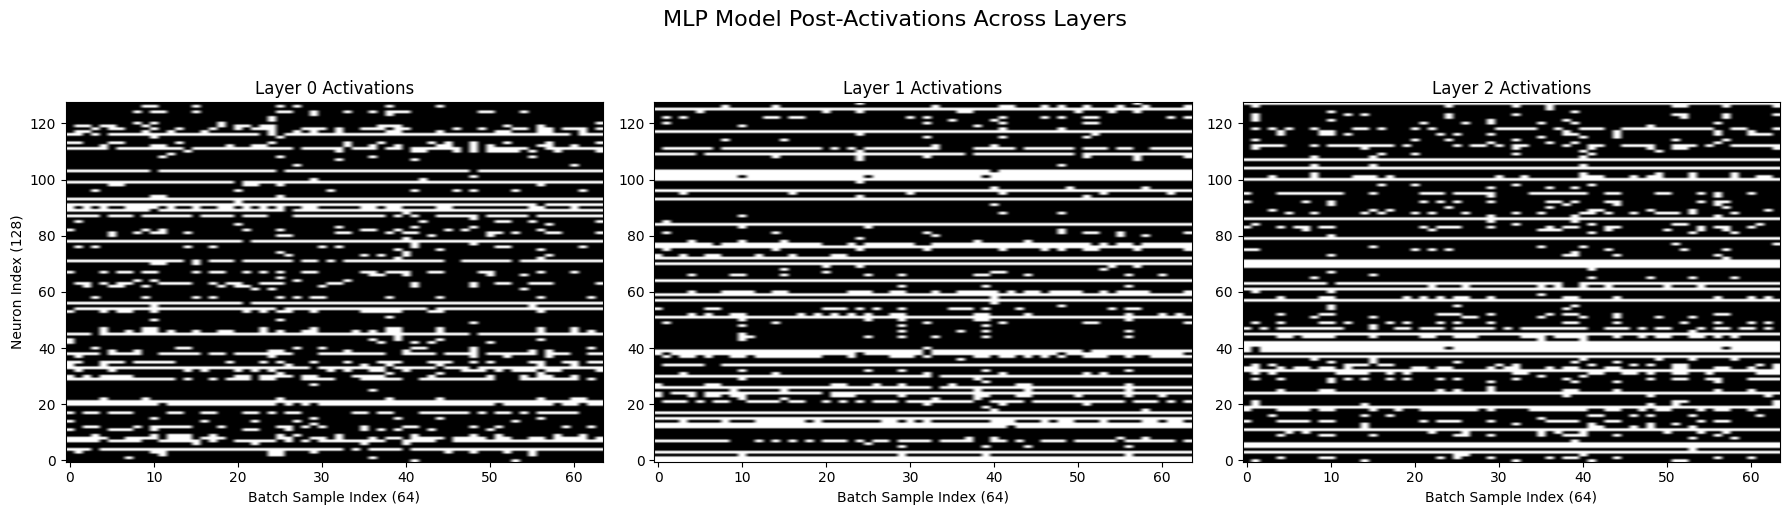

Plotting activations for: BatchNorm MLP Model


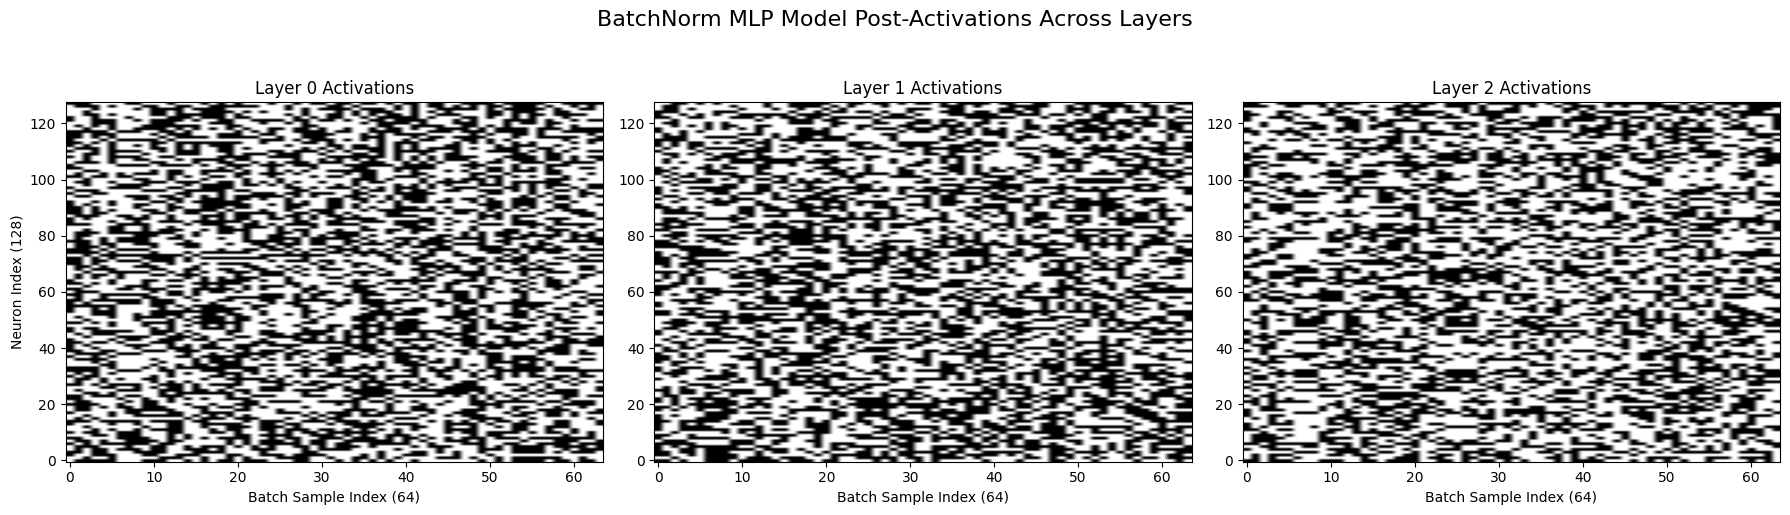

Plotting activations for: LayerNorm MLP Model


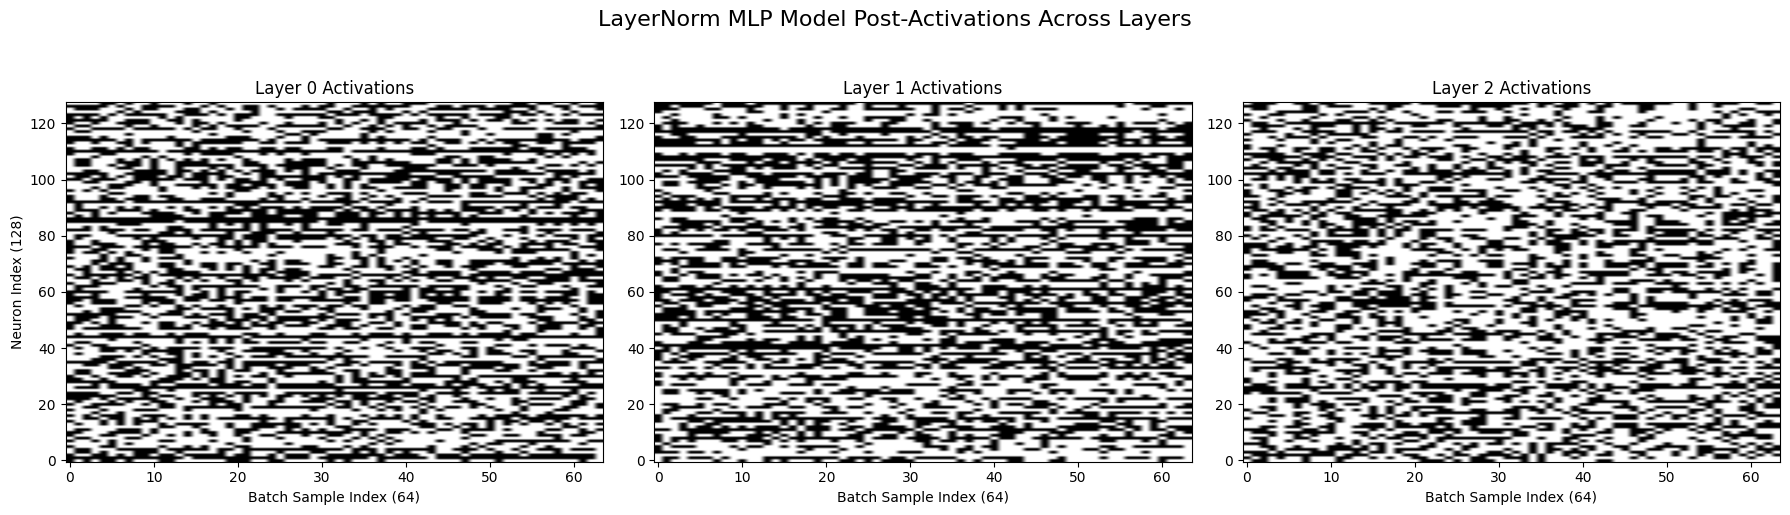

Plotting activations for: GroupNorm MLP Model


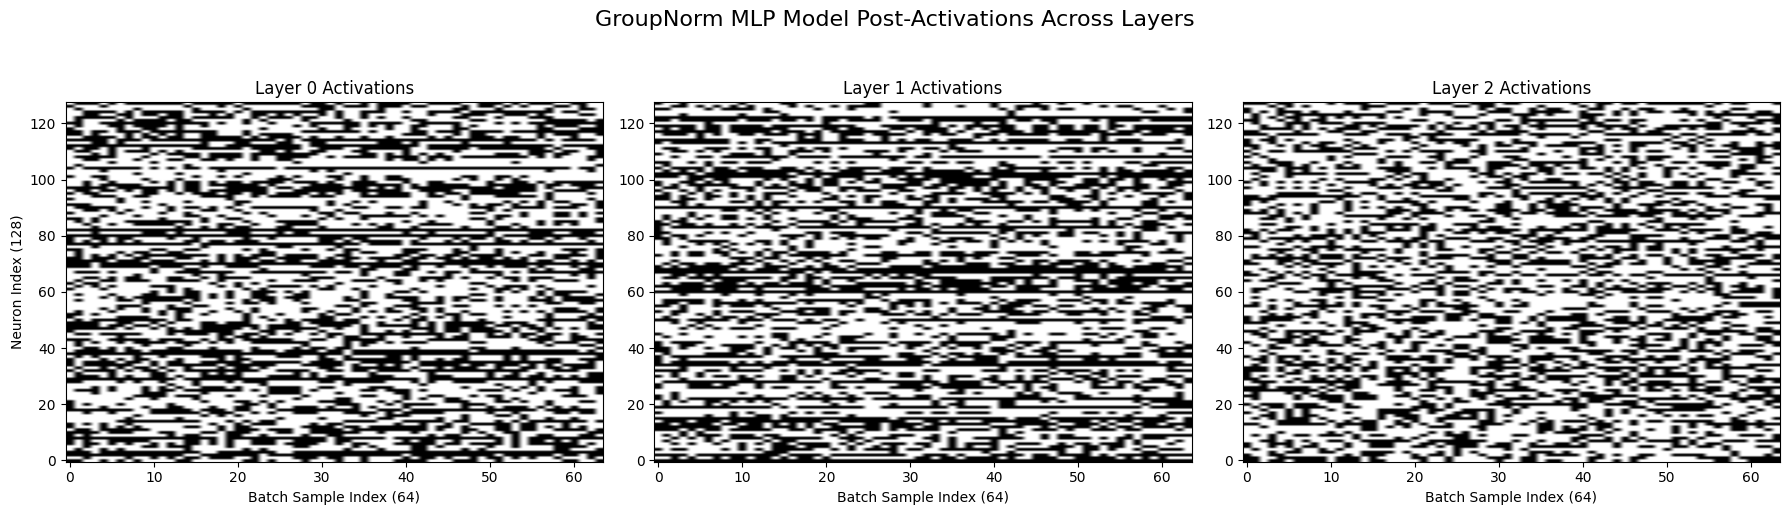

In [9]:
#@title Activation per layer per model
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import seaborn as sns
import torch

def get_post_activations(model, data_loader, device, n_layer=3):
    """Helper function to get post-activations from a specific layer of the model."""
    model.eval() # Set model to evaluation mode
    collected_activations = []
    hooks = []

    def hook_fn(module, input, output):
        collected_activations.append(output.detach())

    # Register hooks on the activation function of each relevant layer
    for layer_idx in range(n_layer):
        # All custom MLP layer classes (MLPLayer, BatchNormMLP, LayerNormMLP, GroupNormMLP)
        # have an 'activation' attribute that we want to hook into.
        # No explicit type checking is needed here as long as the attribute exists.
        hook = model.mlp[layer_idx].activation.register_forward_hook(hook_fn)
        hooks.append(hook)

    with torch.no_grad():
        for data, _ in data_loader:
            data = data.to(device)
            _ = model(data) # Forward pass to trigger the hook
            break # Only process one batch for visualization

    # Remove all hooks after collecting activations
    for hook in hooks:
        hook.remove()

    model.train() # Set model back to training mode

    return collected_activations



all_models = [
    (mlp_model, 'MLP Model'),
    (bn_model, 'BatchNorm MLP Model'),
    (ln_model, 'LayerNorm MLP Model'),
    (gn_model, 'GroupNorm MLP Model')
]

colors = ['white', 'black']
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm([0, 1e-5], cmap.N)

for model, model_name in all_models:
    print(f"Plotting activations for: {model_name}")
    # Get activations for the current model
    current_activations = get_post_activations(model, train_loader, device)

    fig, axes = plt.subplots(1, len(current_activations), figsize=(6 * len(current_activations), 5))
    fig.suptitle(f'{model_name} Post-Activations Across Layers', fontsize=16, y=1.02)

    if len(current_activations) == 1:
        axes = [axes] # Make it iterable if only one subplot

    for i, activation_tensor in enumerate(current_activations):
        data = activation_tensor.cpu().numpy().T
        im = axes[i].imshow(data, cmap=cmap, norm=norm, aspect='auto', origin='lower')

        axes[i].set_title(f'Layer {i} Activations')
        axes[i].set_xlabel('Batch Sample Index (64)')
        if i == 0:
            axes[i].set_ylabel('Neuron Index (128)')

    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to make room for suptitle
    plt.show()
